C:\Users\aswin\AppData\Local\Temp\ipykernel_27500\2909178396.py:41: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


DATASET LOADED SUCCESSFULLY

FIRST 5 ROWS
------------------------------------------------------------
       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12           

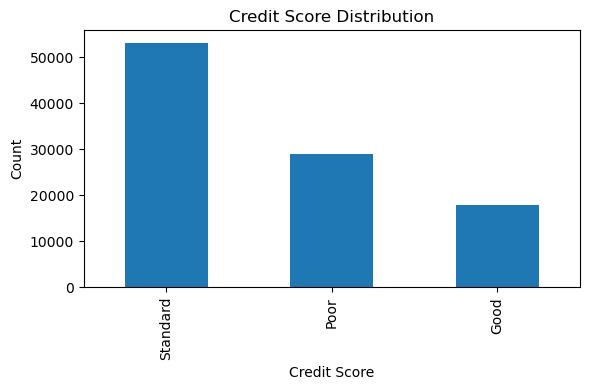


STEP 3 COMPLETED SUCCESSFULLY


In [1]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 3 - Load Dataset
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Dataset Path
# ----------------------------------------------------------

# If notebook is inside the notebooks folder

dataset_path = "../datasets/credit_score.csv"

# If running from project root, use:
# dataset_path = "datasets/credit_score.csv"

# ----------------------------------------------------------
# Check Dataset
# ----------------------------------------------------------

if not os.path.exists(dataset_path):

    print("=" * 60)
    print("ERROR")
    print("=" * 60)
    print("Dataset not found!")
    print(dataset_path)

else:

    # ------------------------------------------------------
    # Load Dataset
    # ------------------------------------------------------

    df = pd.read_csv(dataset_path)

    print("=" * 60)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 60)

    # ------------------------------------------------------
    # First 5 Rows
    # ------------------------------------------------------

    print("\nFIRST 5 ROWS")
    print("-" * 60)
    print(df.head())

    # ------------------------------------------------------
    # Shape
    # ------------------------------------------------------

    print("\nDATASET SHAPE")
    print("-" * 60)
    print(df.shape)

    print("\nRows    :", df.shape[0])
    print("Columns :", df.shape[1])

    # ------------------------------------------------------
    # Data Types
    # ------------------------------------------------------

    print("\nDATA TYPES")
    print("-" * 60)
    print(df.dtypes)

    # ------------------------------------------------------
    # Missing Values
    # ------------------------------------------------------

    print("\nMISSING VALUES")
    print("-" * 60)

    missing = df.isnull().sum()

    print(missing)

    print("\nTotal Missing Values :", missing.sum())

    # ------------------------------------------------------
    # Dataset Info
    # ------------------------------------------------------

    print("\nDATASET INFO")
    print("-" * 60)

    df.info()

    # ------------------------------------------------------
    # Target Distribution
    # ------------------------------------------------------

    if "Credit_Score" in df.columns:

        print("\nTARGET DISTRIBUTION")
        print("-" * 60)

        print(df["Credit_Score"].value_counts())

        print("\nPercentage")

        print(
            round(
                df["Credit_Score"].value_counts(normalize=True) * 100,
                2
            )
        )

        # --------------------------------------------------
        # Plot
        # --------------------------------------------------

        plt.figure(figsize=(6,4))

        df["Credit_Score"].value_counts().plot(kind="bar")

        plt.title("Credit Score Distribution")

        plt.xlabel("Credit Score")

        plt.ylabel("Count")

        plt.tight_layout()

        plt.show()

    else:

        print("\nTarget column 'Credit_Score' not found.")

    print("\n" + "=" * 60)
    print("STEP 3 COMPLETED SUCCESSFULLY")
    print("=" * 60)

In [2]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 4 - Data Cleaning
# ==========================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STEP 4 - DATA CLEANING")
print("=" * 70)

# ----------------------------------------------------------
# Dataset Shape Before Cleaning
# ----------------------------------------------------------

print("\nDataset Shape Before Cleaning")
print(df.shape)

# ==========================================================
# Missing Values
# ==========================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

# ==========================================================
# Duplicate Rows
# ==========================================================

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

if duplicates > 0:

    df.drop_duplicates(inplace=True)

    print("Duplicates Removed")

else:

    print("No Duplicate Rows Found")

# ==========================================================
# Replace Invalid Values
# ==========================================================

print("\n" + "=" * 70)
print("REPLACING INVALID VALUES")
print("=" * 70)

invalid_values = [

    "_______",

    "_",

    "NA",

    "N/A",

    "",

    " "

]

df.replace(
    invalid_values,
    np.nan,
    inplace=True
)

print("Invalid Values Replaced with NaN")

# ==========================================================
# Remove Extra Spaces
# ==========================================================

for column in df.columns:

    if df[column].dtype == object:

        df[column] = df[column].astype(str).str.strip()

# ==========================================================
# Numeric Columns
# ==========================================================

numeric_columns = [

    "Age",

    "Annual_Income",

    "Monthly_Inhand_Salary",

    "Num_Bank_Accounts",

    "Num_Credit_Card",

    "Interest_Rate",

    "Num_of_Loan",

    "Delay_from_due_date",

    "Num_of_Delayed_Payment",

    "Changed_Credit_Limit",

    "Outstanding_Debt",

    "Credit_Utilization_Ratio",

    "Monthly_Balance"

]

print("\nConverting Numeric Columns...")

for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(

            df[column],

            errors="coerce"

        )

print("Conversion Completed")

# ==========================================================
# Check Data Types
# ==========================================================

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

# ==========================================================
# Fill Missing Values
# ==========================================================

print("\n" + "=" * 70)
print("FILLING MISSING VALUES")
print("=" * 70)

for column in numeric_columns:

    if column in df.columns:

        df[column].fillna(

            df[column].median(),

            inplace=True

        )

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:

    df[column].fillna(

        df[column].mode()[0],

        inplace=True

    )

print("Missing Values Filled")

# ==========================================================
# Outlier Detection (IQR Method)
# ==========================================================

print("\n" + "=" * 70)
print("OUTLIER DETECTION")
print("=" * 70)

for column in numeric_columns:

    if column in df.columns:

        Q1 = df[column].quantile(0.25)

        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        outliers = ((df[column] < lower) | (df[column] > upper)).sum()

        print(f"{column:<30} {outliers}")

# ==========================================================
# Clip Outliers
# ==========================================================

print("\nClipping Outliers...")

for column in numeric_columns:

    if column in df.columns:

        Q1 = df[column].quantile(0.25)

        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        df[column] = df[column].clip(

            lower,

            upper

        )

print("Outliers Clipped Successfully")

# ==========================================================
# Final Check
# ==========================================================

print("\n" + "=" * 70)
print("FINAL DATASET")
print("=" * 70)

print("Shape :", df.shape)

print("\nRemaining Missing Values")

print(df.isnull().sum())

print("\nFirst Five Rows")

print(df.head())

# ==========================================================
# Save Clean Dataset
# ==========================================================

df.to_csv(

    "../datasets/credit_score_cleaned.csv",

    index=False

)

print("\nCleaned Dataset Saved Successfully")

print("../datasets/credit_score_cleaned.csv")

print("\n" + "=" * 70)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 70)

STEP 4 - DATA CLEANING

Dataset Shape Before Cleaning
(100000, 28)

MISSING VALUES
ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200

C:\Users\aswin\AppData\Local\Temp\ipykernel_27500\658201782.py:167: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(
C:\Users\aswin\AppData\Local\Temp\ipykernel_27500\658201782.py:179: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

Missing Values Filled

OUTLIER DETECTION
Age                            2696
Annual_Income                  3196
Monthly_Inhand_Salary          4365
Num_Bank_Accounts              1315
Num_Credit_Card                2271
Interest_Rate                  2034
Num_of_Loan                    4323
Delay_from_due_date            4002
Num_of_Delayed_Payment         717
Changed_Credit_Limit           1177
Outstanding_Debt               5441
Credit_Utilization_Ratio       4
Monthly_Balance                7864

Clipping Outliers...
Outliers Clipped Successfully

FINAL DATASET
Shape : (100000, 28)

Remaining Missing Values
ID                             0
Customer_ID                    0
Month                          0
Name                           0
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate     

STEP 5 - EXPLORATORY DATA ANALYSIS

Dataset Shape
(100000, 28)

Credit Score Distribution
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


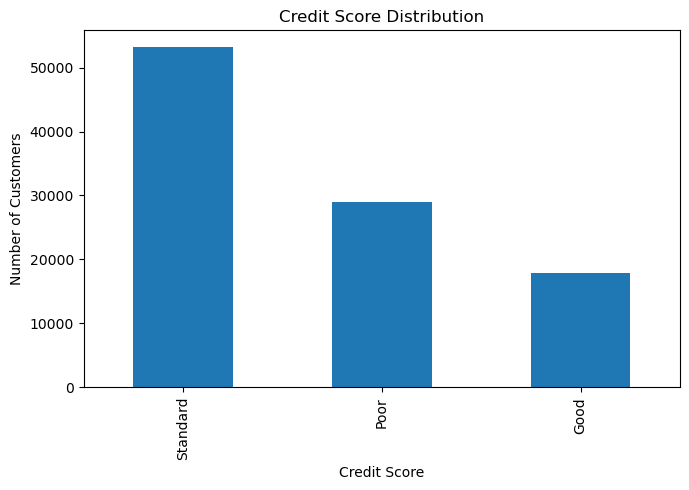

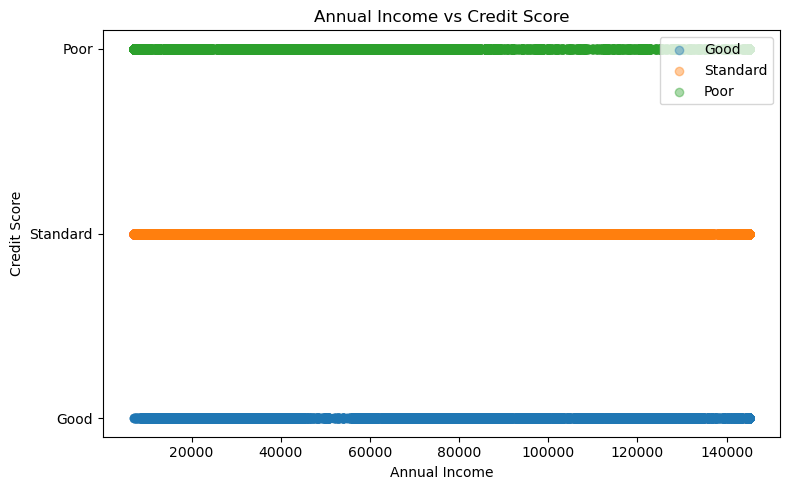

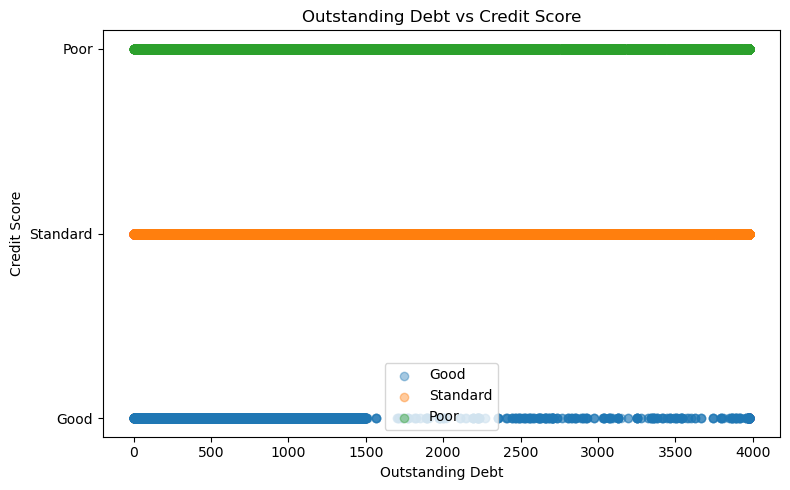

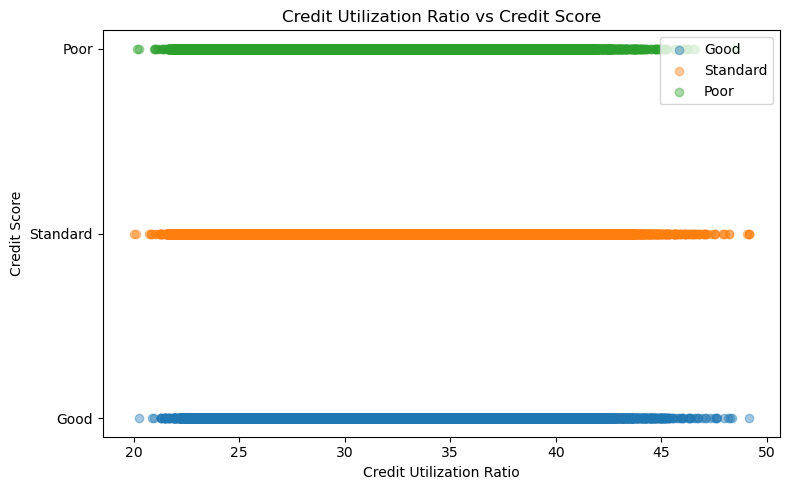

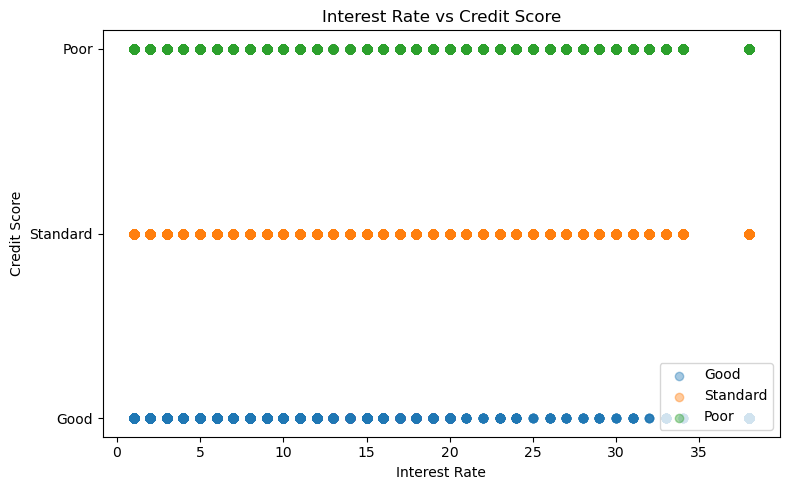


Generating Correlation Matrix...


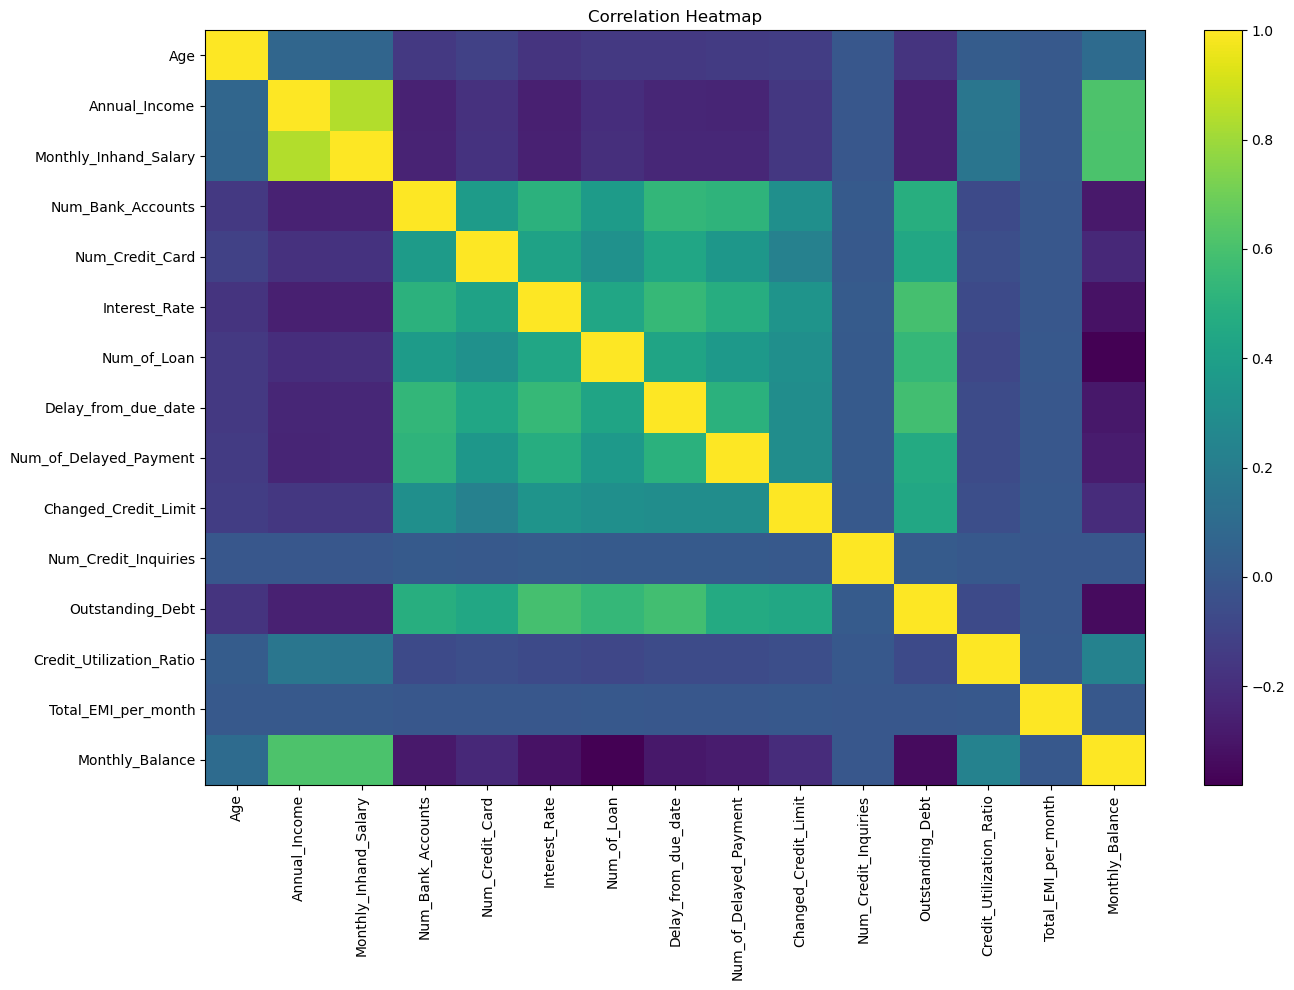


Correlation Matrix
                               Age  Annual_Income  Monthly_Inhand_Salary  \
Age                       1.000000       0.075101               0.071594   
Annual_Income             0.075101       1.000000               0.840565   
Monthly_Inhand_Salary     0.071594       0.840565               1.000000   
Num_Bank_Accounts        -0.152849      -0.247970              -0.240369   
Num_Credit_Card          -0.113738      -0.182345              -0.180131   
Interest_Rate            -0.172647      -0.256807              -0.253064   
Num_of_Loan              -0.151587      -0.199108              -0.195835   
Delay_from_due_date      -0.152197      -0.233931              -0.227935   
Num_of_Delayed_Payment   -0.141803      -0.236307              -0.228872   
Changed_Credit_Limit     -0.131437      -0.157116              -0.154772   
Num_Credit_Inquiries     -0.006371      -0.007380              -0.008115   
Outstanding_Debt         -0.175096      -0.253002              -0.25

In [3]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 5 - Exploratory Data Analysis (EDA)
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("STEP 5 - EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# ==========================================================
# Dataset Shape
# ==========================================================

print("\nDataset Shape")
print(df.shape)

# ==========================================================
# Credit Score Distribution
# ==========================================================

print("\nCredit Score Distribution")

print(df["Credit_Score"].value_counts())

plt.figure(figsize=(7,5))

df["Credit_Score"].value_counts().plot(
    kind="bar"
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# ==========================================================
# Annual Income vs Credit Score
# ==========================================================

plt.figure(figsize=(8,5))

for score in df["Credit_Score"].unique():

    subset = df[df["Credit_Score"] == score]

    plt.scatter(

        subset["Annual_Income"],

        subset["Credit_Score"],

        alpha=0.4,

        label=score

    )

plt.title("Annual Income vs Credit Score")

plt.xlabel("Annual Income")

plt.ylabel("Credit Score")

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Outstanding Debt vs Credit Score
# ==========================================================

plt.figure(figsize=(8,5))

for score in df["Credit_Score"].unique():

    subset = df[df["Credit_Score"] == score]

    plt.scatter(

        subset["Outstanding_Debt"],

        subset["Credit_Score"],

        alpha=0.4,

        label=score

    )

plt.title("Outstanding Debt vs Credit Score")

plt.xlabel("Outstanding Debt")

plt.ylabel("Credit Score")

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Credit Utilization vs Credit Score
# ==========================================================

plt.figure(figsize=(8,5))

for score in df["Credit_Score"].unique():

    subset = df[df["Credit_Score"] == score]

    plt.scatter(

        subset["Credit_Utilization_Ratio"],

        subset["Credit_Score"],

        alpha=0.4,

        label=score

    )

plt.title("Credit Utilization Ratio vs Credit Score")

plt.xlabel("Credit Utilization Ratio")

plt.ylabel("Credit Score")

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Interest Rate vs Credit Score
# ==========================================================

plt.figure(figsize=(8,5))

for score in df["Credit_Score"].unique():

    subset = df[df["Credit_Score"] == score]

    plt.scatter(

        subset["Interest_Rate"],

        subset["Credit_Score"],

        alpha=0.4,

        label=score

    )

plt.title("Interest Rate vs Credit Score")

plt.xlabel("Interest Rate")

plt.ylabel("Credit Score")

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Correlation Heatmap
# ==========================================================

print("\nGenerating Correlation Matrix...")

numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=90

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# ==========================================================
# Top Correlated Features
# ==========================================================

print("\nCorrelation Matrix")

print(corr)

# ==========================================================
# Summary Statistics
# ==========================================================

print("\nSummary Statistics")

print(df.describe())

print("\n" + "=" * 70)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 70)

In [8]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 6 - Feature Engineering (Corrected)
# ==========================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

print("="*70)
print("STEP 6 - FEATURE ENGINEERING")
print("="*70)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../datasets/credit_score.csv")

print("\nDataset Loaded")
print(df.shape)

# ==========================================================
# Remove Unnecessary Columns
# ==========================================================

drop_columns = [

    "ID",
    "Customer_ID",
    "Name",
    "SSN",
    "Month"

]

for col in drop_columns:

    if col in df.columns:

        df.drop(col, axis=1, inplace=True)

print("\nUnnecessary Columns Removed")

# ==========================================================
# Replace Invalid Values
# ==========================================================

df.replace("_______", np.nan, inplace=True)
df.replace("NA", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)

# ==========================================================
# Convert Numeric Columns
# ==========================================================

numeric_columns = [

    "Age",

    "Annual_Income",

    "Monthly_Inhand_Salary",

    "Num_Bank_Accounts",

    "Num_Credit_Card",

    "Interest_Rate",

    "Num_of_Loan",

    "Delay_from_due_date",

    "Num_of_Delayed_Payment",

    "Changed_Credit_Limit",

    "Outstanding_Debt",

    "Credit_Utilization_Ratio",

    "Monthly_Balance"

]

for col in numeric_columns:

    if col in df.columns:

        df[col] = (

            df[col]

            .astype(str)

            .str.replace("_","",regex=False)

            .str.replace(",","",regex=False)

        )

        df[col] = pd.to_numeric(

            df[col],

            errors="coerce"

        )

# ==========================================================
# Fill Missing Numeric Values
# ==========================================================

for col in numeric_columns:

    if col in df.columns:

        df[col] = df[col].fillna(

            df[col].median()

        )

# ==========================================================
# Fill Missing Categorical Values
# ==========================================================

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    if col != "Credit_Score":

        df[col] = df[col].fillna(

            df[col].mode()[0]

        )

# ==========================================================
# Encode Target
# ==========================================================

target_encoder = LabelEncoder()

df["Credit_Score"] = target_encoder.fit_transform(

    df["Credit_Score"]

)

print("\nTarget Classes")

for i, c in enumerate(target_encoder.classes_):

    print(i, "->", c)

# ==========================================================
# Encode Categorical Columns
# ==========================================================

categorical_columns = []

for col in df.select_dtypes(include="object").columns:

    if col != "Credit_Score":

        if df[col].nunique() <= 10:

            categorical_columns.append(col)

        else:

            le = LabelEncoder()

            df[col] = le.fit_transform(

                df[col].astype(str)

            )

if len(categorical_columns) > 0:

    df = pd.get_dummies(

        df,

        columns=categorical_columns,

        drop_first=True

    )

print("\nCategorical Encoding Completed")

# ==========================================================
# Final NaN Check
# ==========================================================

print("\nMissing Values Before Scaling")

print(df.isnull().sum().sum())

df.fillna(0, inplace=True)

print("Missing Values After Filling")

print(df.isnull().sum().sum())

# ==========================================================
# Scaling
# ==========================================================

X = df.drop("Credit_Score", axis=1)

y = df["Credit_Score"]

feature_names = X.columns.tolist()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(

    X_scaled,

    columns=feature_names

)

scaled_df["Credit_Score"] = y

# ==========================================================
# Save Files
# ==========================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(

    scaler,

    "../models/credit_scaler.pkl"

)

joblib.dump(

    target_encoder,

    "../models/credit_target_encoder.pkl"

)

joblib.dump(

    feature_names,

    "../models/credit_feature_names.pkl"

)

scaled_df.to_csv(

    "../datasets/credit_score_encoded.csv",

    index=False

)

print("\nEncoded Dataset Saved")

print("../datasets/credit_score_encoded.csv")

print("\nScaler Saved")

print("../models/credit_scaler.pkl")

print("\nTarget Encoder Saved")

print("../models/credit_target_encoder.pkl")

print("\nFeature Names Saved")

print("../models/credit_feature_names.pkl")

print("\nDataset Shape")

print(scaled_df.shape)

print("\nRemaining Missing Values")

print(scaled_df.isnull().sum().sum())

print("\n"+"="*70)

print("STEP 6 COMPLETED SUCCESSFULLY")

print("="*70)

STEP 6 - FEATURE ENGINEERING


C:\Users\aswin\AppData\Local\Temp\ipykernel_27500\1136433955.py:25: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/credit_score.csv")



Dataset Loaded
(100000, 28)

Unnecessary Columns Removed

Target Classes
0 -> Good
1 -> Poor
2 -> Standard

Categorical Encoding Completed

Missing Values Before Scaling
1965
Missing Values After Filling
0

Encoded Dataset Saved
../datasets/credit_score_encoded.csv

Scaler Saved
../models/credit_scaler.pkl

Target Encoder Saved
../models/credit_target_encoder.pkl

Feature Names Saved
../models/credit_feature_names.pkl

Dataset Shape
(100000, 31)

Remaining Missing Values
0

STEP 6 COMPLETED SUCCESSFULLY


In [9]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 7 - Train/Test Split
# ==========================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

print("=" * 70)
print("STEP 7 - TRAIN / TEST SPLIT")
print("=" * 70)

# ==========================================================
# Load Processed Dataset
# ==========================================================

dataset_path = "../datasets/credit_score_encoded.csv"

df = pd.read_csv(dataset_path)

print("\nDataset Loaded Successfully")

print("Shape :", df.shape)

# ==========================================================
# Features and Target
# ==========================================================

X = df.drop("Credit_Score", axis=1)

y = df["Credit_Score"]

print("\nFeature Shape :", X.shape)

print("Target Shape  :", y.shape)

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Samples :", len(X_train))

print("Testing Samples  :", len(X_test))

# ==========================================================
# Create Processed Folder
# ==========================================================

processed_path = "../datasets/processed"

os.makedirs(

    processed_path,

    exist_ok=True

)

# ==========================================================
# Save Train/Test Data
# ==========================================================

np.save(

    os.path.join(processed_path, "credit_X_train.npy"),

    X_train.values

)

np.save(

    os.path.join(processed_path, "credit_X_test.npy"),

    X_test.values

)

np.save(

    os.path.join(processed_path, "credit_y_train.npy"),

    y_train.values

)

np.save(

    os.path.join(processed_path, "credit_y_test.npy"),

    y_test.values

)

print("\nTrain/Test Files Saved Successfully")

print("\nSaved Files:")

print("credit_X_train.npy")

print("credit_X_test.npy")

print("credit_y_train.npy")

print("credit_y_test.npy")

# ==========================================================
# Target Distribution
# ==========================================================

print("\nTraining Target Distribution")

print(y_train.value_counts())

print("\nTesting Target Distribution")

print(y_test.value_counts())

# ==========================================================
# Final Summary
# ==========================================================

print("\n" + "=" * 70)

print("STEP 7 COMPLETED SUCCESSFULLY")

print("=" * 70)

print("\nReady for Step 8 - Model Training")

STEP 7 - TRAIN / TEST SPLIT

Dataset Loaded Successfully
Shape : (100000, 31)

Feature Shape : (100000, 30)
Target Shape  : (100000,)

Training Samples : 80000
Testing Samples  : 20000

Train/Test Files Saved Successfully

Saved Files:
credit_X_train.npy
credit_X_test.npy
credit_y_train.npy
credit_y_test.npy

Training Target Distribution
Credit_Score
2    42539
1    23199
0    14262
Name: count, dtype: int64

Testing Target Distribution
Credit_Score
2    10635
1     5799
0     3566
Name: count, dtype: int64

STEP 7 COMPLETED SUCCESSFULLY

Ready for Step 8 - Model Training


In [13]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 8 - Train Multiple Models
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# Load Processed Data
# ==========================================================

X_train = np.load(
    "../datasets/processed/credit_X_train.npy",
    allow_pickle=True
)

X_test = np.load(
    "../datasets/processed/credit_X_test.npy",
    allow_pickle=True
)

y_train = np.load(
    "../datasets/processed/credit_y_train.npy",
    allow_pickle=True
)

y_test = np.load(
    "../datasets/processed/credit_y_test.npy",
    allow_pickle=True
)

print("="*70)
print("TRAINING DATA LOADED")
print("="*70)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

# ==========================================================
# Remove NaN Values
# ==========================================================

X_train = np.nan_to_num(X_train)

X_test = np.nan_to_num(X_test)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=500,
        random_state=42
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

}

# ==========================================================
# Training
# ==========================================================

results=[]

best_model=None

best_name=""

best_f1=0

print("\n")
print("="*70)
print("MODEL TRAINING")
print("="*70)

for name,model in models.items():

    print(f"\nTraining {name}")

    model.fit(
        X_train,
        y_train
    )

    pred=model.predict(
        X_test
    )

    accuracy=accuracy_score(
        y_test,
        pred
    )

    precision=precision_score(
        y_test,
        pred,
        average="weighted"
    )

    recall=recall_score(
        y_test,
        pred,
        average="weighted"
    )

    f1=f1_score(
        y_test,
        pred,
        average="weighted"
    )

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])

    print("Accuracy :",round(accuracy,4))
    print("Precision:",round(precision,4))
    print("Recall   :",round(recall,4))
    print("F1 Score :",round(f1,4))

    print("\nConfusion Matrix")

    print(
        confusion_matrix(
            y_test,
            pred
        )
    )

    if f1>best_f1:

        best_f1=f1

        best_model=model

        best_name=name

# ==========================================================
# Results
# ==========================================================

results_df=pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

results_df=results_df.sort_values(

    by="F1 Score",

    ascending=False

)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

# ==========================================================
# Save Model
# ==========================================================

os.makedirs("../models",exist_ok=True)

joblib.dump(

    best_model,

    "../models/credit_score_model.pkl",

    compress=3

)

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print(best_name)

print("F1 Score :",round(best_f1,4))

print("\nModel Saved")

print("../models/credit_score_model.pkl")

TRAINING DATA LOADED
Training : (80000, 30)
Testing  : (20000, 30)


MODEL TRAINING

Training Logistic Regression
Accuracy : 0.622
Precision: 0.6253
Recall   : 0.622
F1 Score : 0.6165

Confusion Matrix
[[2166   84 1316]
 [ 526 2543 2730]
 [1553 1352 7730]]

Training Decision Tree
Accuracy : 0.7093
Precision: 0.7143
Recall   : 0.7093
F1 Score : 0.7109

Confusion Matrix
[[2377  133 1056]
 [ 401 3977 1421]
 [1376 1427 7832]]

Training Random Forest
Accuracy : 0.7522
Precision: 0.7556
Recall   : 0.7522
F1 Score : 0.7533

Confusion Matrix
[[2559   46  961]
 [ 328 4240 1231]
 [1151 1239 8245]]


MODEL COMPARISON
                 Model  Accuracy  Precision   Recall  F1 Score
2        Random Forest   0.75220   0.755578  0.75220  0.753261
1        Decision Tree   0.70930   0.714269  0.70930  0.710939
0  Logistic Regression   0.62195   0.625337  0.62195  0.616525


BEST MODEL
Random Forest
F1 Score : 0.7533

Model Saved
../models/credit_score_model.pkl


In [14]:
# ==========================================================
# AI Banking Assistant
# Module 7 - Credit Score Prediction
# Step 9 - Evaluate Models
# ==========================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

print("=" * 70)
print("STEP 9 - MODEL EVALUATION")
print("=" * 70)

# ==========================================================
# Load Train/Test Data
# ==========================================================

X_train = np.load("../datasets/processed/credit_X_train.npy")
X_test = np.load("../datasets/processed/credit_X_test.npy")

y_train = np.load("../datasets/processed/credit_y_train.npy")
y_test = np.load("../datasets/processed/credit_y_test.npy")

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )

}

# ==========================================================
# Evaluate Models
# ==========================================================

results = []

best_model = None
best_model_name = ""
best_f1 = 0

for name, model in models.items():

    print("\n" + "=" * 70)
    print("Model :", name)
    print("=" * 70)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, prediction))

    print("\nClassification Report")
    print(classification_report(y_test, prediction))

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

# ==========================================================
# Comparison Table
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results_df)

# ==========================================================
# Save Best Model
# ==========================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/credit_score_model.pkl"
)

print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Best Model :", best_model_name)
print("Best F1 Score :", round(best_f1,4))

print("\nModel Saved Successfully")

print("../models/credit_score_model.pkl")

print("\n" + "=" * 70)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("=" * 70)

STEP 9 - MODEL EVALUATION

Training Shape : (80000, 30)
Testing Shape  : (20000, 30)

Model : Logistic Regression
Accuracy : 0.622
Precision: 0.6253
Recall   : 0.622
F1 Score : 0.6165

Confusion Matrix
[[2166   84 1316]
 [ 526 2543 2730]
 [1553 1352 7730]]

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.61      0.55      3566
           1       0.64      0.44      0.52      5799
           2       0.66      0.73      0.69     10635

    accuracy                           0.62     20000
   macro avg       0.60      0.59      0.59     20000
weighted avg       0.63      0.62      0.62     20000


Model : Decision Tree
Accuracy : 0.6963
Precision: 0.6966
Recall   : 0.6963
F1 Score : 0.6965

Confusion Matrix
[[2226  175 1165]
 [ 156 3985 1658]
 [1212 1708 7715]]

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.62      0.62      3566
           1       0.68      0.69      

In [15]:
# ==========================================================
# Step 10 - Save Best Model
# ==========================================================

import os
import joblib

# Create ml/models folder
os.makedirs("../ml/models", exist_ok=True)

# Save Best ML Model
joblib.dump(
    best_model,
    "../ml/models/credit_score_model.pkl"
)

# Save Scaler
joblib.dump(
    scaler,
    "../ml/models/credit_scaler.pkl"
)

# Save Target Encoder
joblib.dump(
    target_encoder,
    "../ml/models/credit_target_encoder.pkl"
)

# Save Feature Names
joblib.dump(
    feature_names,
    "../ml/models/credit_feature_names.pkl"
)

print("="*70)
print("MODEL SAVED SUCCESSFULLY")
print("="*70)

print("credit_score_model.pkl")
print("credit_scaler.pkl")
print("credit_target_encoder.pkl")
print("credit_feature_names.pkl")

MODEL SAVED SUCCESSFULLY
credit_score_model.pkl
credit_scaler.pkl
credit_target_encoder.pkl
credit_feature_names.pkl
